In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

# ── PK parameters ──────────────────────────────────────────────────────────
ka   = 1.2    # absorption rate constant  (h⁻¹)
ke   = 0.15   # elimination rate constant (h⁻¹)
V    = 30.0   # volume of distribution    (L)
F    = 0.85   # bioavailability
doses = [100, 250, 500]   # mg

t = np.linspace(0.01, 48, 500)   # time vector 0–48 h

def one_compartment(t, D, ka, ke, V, F):
    """Oral one-compartment PK model (mg/L)."""
    return (F * D * ka) / (V * (ka - ke)) * (np.exp(-ke * t) - np.exp(-ka * t))

# Add simulated observed data points (with log-normal noise)
rng = np.random.default_rng(42)
t_obs = np.array([0.5, 1, 2, 4, 6, 8, 12, 24, 36, 48])

# ── Colours and styles ────────────────────────────────────────────────────
colors  = ['#2196F3', '#FF5722', '#4CAF50']
markers = ['o', 's', '^']



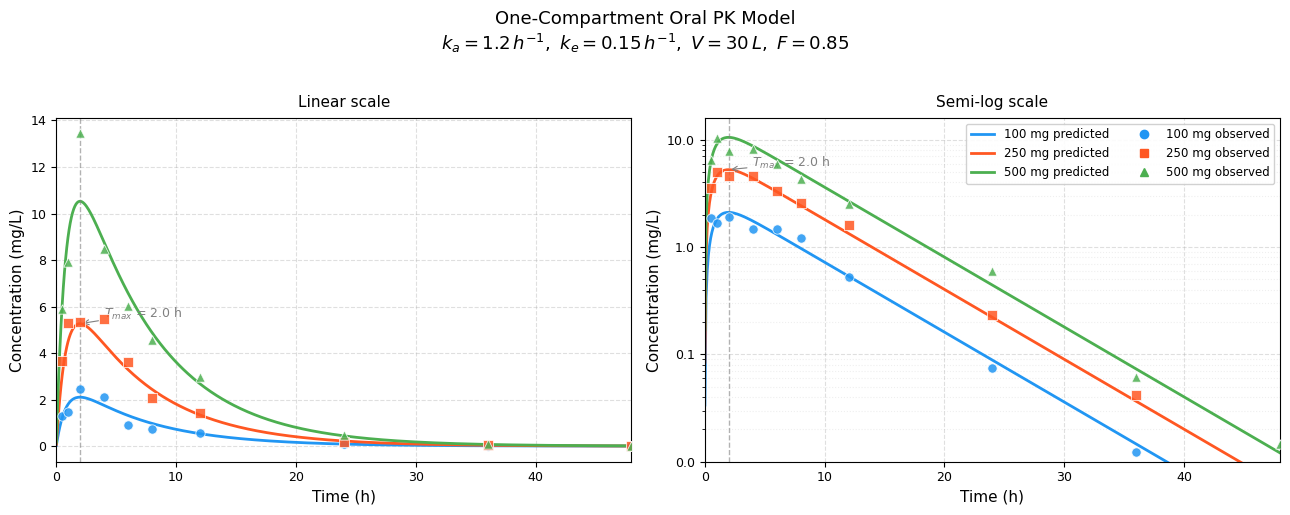

Saved as pk_curves.png


In [2]:
# ── Figure: two panels side by side ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('One-Compartment Oral PK Model\n'
             r'$k_a=1.2\,h^{-1},\ k_e=0.15\,h^{-1},\ V=30\,L,\ F=0.85$',
             fontsize=13, y=1.02)

for ax, yscale, title in zip(axes,
                              ['linear', 'log'],
                              ['Linear scale', 'Semi-log scale']):

    for dose, color, marker in zip(doses, colors, markers):
        conc      = one_compartment(t, dose, ka, ke, V, F)
        conc_obs  = one_compartment(t_obs, dose, ka, ke, V, F)
        # simulate observed with ~20% CV log-normal noise
        conc_noisy = conc_obs * rng.lognormal(0, 0.2, size=len(t_obs))

        # Predicted line
        ax.plot(t, conc, color=color, lw=2,
                label=f'{dose} mg')

        # Simulated observations
        ax.scatter(t_obs, conc_noisy,
                   color=color, marker=marker,
                   s=45, zorder=5, alpha=0.85,
                   edgecolors='white', linewidths=0.6)

    # Mark Tmax for 250 mg dose
    tmax = np.log(ka / ke) / (ka - ke)
    cmax = one_compartment(tmax, 250, ka, ke, V, F)
    ax.axvline(tmax, color='grey', lw=1, ls='--', alpha=0.6)
    ax.annotate(f'$T_{{max}}$ = {tmax:.1f} h',
                xy=(tmax, cmax), xytext=(tmax + 2, cmax * 1.05),
                fontsize=9, color='grey',
                arrowprops=dict(arrowstyle='->', color='grey', lw=0.8))

    ax.set_yscale(yscale)
    ax.set_xlabel('Time (h)', fontsize=11)
    ax.set_ylabel('Concentration (mg/L)', fontsize=11)
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_xlim(0, 48)
    ax.tick_params(labelsize=9)
    ax.grid(True, which='major', ls='--', alpha=0.4)
    ax.grid(True, which='minor', ls=':', alpha=0.2)

    if yscale == 'log':
        ax.set_ylim(0.01, None)
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

# ── Shared legend (lines = predicted, markers = observed) ─────────────────
legend_lines = [
    Line2D([0], [0], color=c, lw=2, label=f'{d} mg predicted')
    for d, c in zip(doses, colors)
]
legend_markers = [
    Line2D([0], [0], color=c, marker=m, lw=0,
           markersize=6, label=f'{d} mg observed')
    for d, c, m in zip(doses, colors, markers)
]
axes[1].legend(handles=legend_lines + legend_markers,
               ncol=2, fontsize=8.5,
               loc='upper right',
               framealpha=0.9, edgecolor='#cccccc')

fig.tight_layout()
plt.savefig('pk_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved as pk_curves.png')